<a href="https://colab.research.google.com/github/AlbertPuentes/Deep-Learning-week5_Actvidad_5./blob/main/Semana_5_Actividad_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importación de librerías necesarias
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Fijar semilla para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

# 1. Cargar y preparar el dataset MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalizar los valores de los píxeles (de 0-255 a 0.0-1.0)
x_train = x_train / 255.0
x_test = x_test / 255.0

print(f"Forma de x_train: {x_train.shape}")
print(f"Forma de y_train: {y_train.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forma de x_train: (60000, 28, 28)
Forma de y_train: (60000,)


In [ ]:
# Función para crear el modelo base
# Esto garantiza que ambas configuraciones inicien con la misma arquitectura
def crear_modelo():
    modelo = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),          # Capa de entrada (aplanar la imagen)
        layers.Dense(128, activation='relu'),          # Capa oculta 1
        layers.Dense(64, activation='relu'),           # Capa oculta 2
        layers.Dense(10, activation='softmax')         # Capa de salida (10 clases para multiclase)
    ])
    return modelo

# Parámetros constantes
EPOCHS = 10
BATCH_SIZE = 64

In [ ]:
# CONFIGURACIÓN 1: Optimizador ADAM (LR = 0.001)
print("--- Iniciando Entrenamiento Configuración 1 (ADAM) ---")
modelo_adam = crear_modelo()

optimizador_adam = tf.keras.optimizers.Adam(learning_rate=0.001)

modelo_adam.compile(optimizer=optimizador_adam,
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

historial_adam = modelo_adam.fit(x_train, y_train,
                                 epochs=EPOCHS,
                                 batch_size=BATCH_SIZE,
                                 validation_data=(x_test, y_test),
                                 verbose=1)

# CONFIGURACIÓN 2: Optimizador SGD (LR = 0.01)
print("\n--- Iniciando Entrenamiento Configuración 2 (SGD) ---")
modelo_sgd = crear_modelo()

optimizador_sgd = tf.keras.optimizers.SGD(learning_rate=0.01)

modelo_sgd.compile(optimizer=optimizador_sgd,
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

historial_sgd = modelo_sgd.fit(x_train, y_train,
                               epochs=EPOCHS,
                               batch_size=BATCH_SIZE,
                               validation_data=(x_test, y_test),
                               verbose=1)

--- Iniciando Entrenamiento Configuración 1 (ADAM) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9191 - loss: 0.2786 - val_accuracy: 0.9579 - val_loss: 0.1375
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9657 - loss: 0.1142 - val_accuracy: 0.9680 - val_loss: 0.1025
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9772 - loss: 0.0778 - val_accuracy: 0.9736 - val_loss: 0.0834
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9826 - loss: 0.0583 - val_accuracy: 0.9760 - val_loss: 0.0791
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9869 - loss: 0.0439 - val_accuracy: 0.9783 - val_loss: 0.0755
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9902 - loss: 0.0344 - val_accuracy: 0.9776 - val_loss: 0.0768
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9917 - loss: 0.0277 - val_accuracy: 0.9791 - val_loss: 0.0805
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9930 - loss: 0.0228 - val_accuracy: 0.

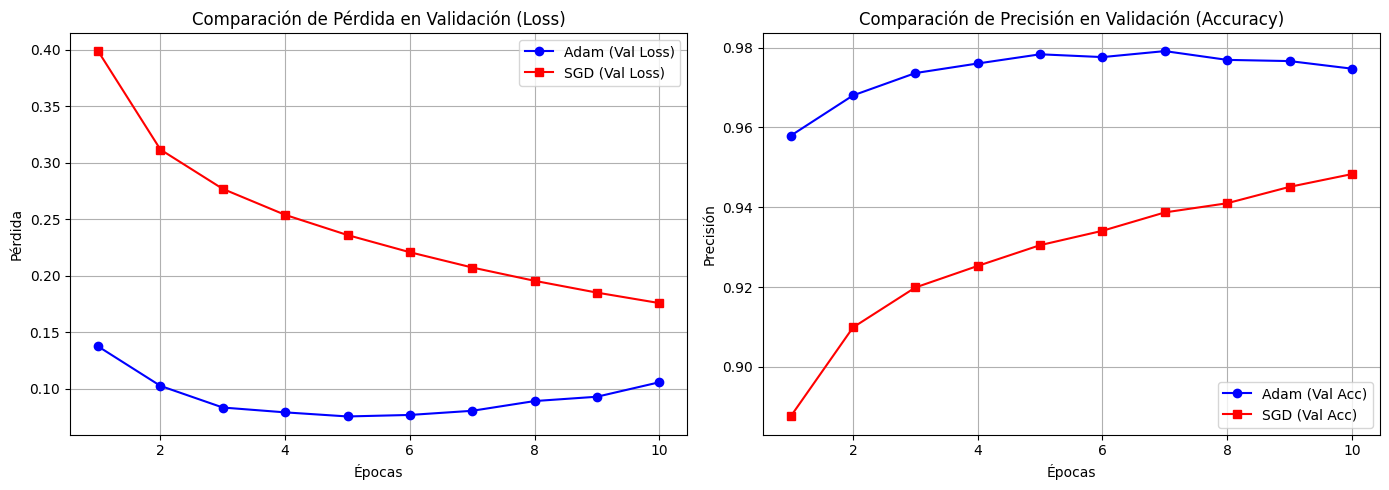

In [ ]:
# Extraer datos de los historiales
loss_adam = historial_adam.history['loss']
val_loss_adam = historial_adam.history['val_loss']
acc_adam = historial_adam.history['accuracy']
val_acc_adam = historial_adam.history['val_accuracy']

loss_sgd = historial_sgd.history['loss']
val_loss_sgd = historial_sgd.history['val_loss']
acc_sgd = historial_sgd.history['accuracy']
val_acc_sgd = historial_sgd.history['val_accuracy']

epocas_rango = range(1, EPOCHS + 1)

# Crear la figura
plt.figure(figsize=(14, 5))

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(epocas_rango, val_loss_adam, 'b-', label='Adam (Val Loss)', marker='o')
plt.plot(epocas_rango, val_loss_sgd, 'r-', label='SGD (Val Loss)', marker='s')
plt.title('Comparación de Pérdida en Validación (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epocas_rango, val_acc_adam, 'b-', label='Adam (Val Acc)', marker='o')
plt.plot(epocas_rango, val_acc_sgd, 'r-', label='SGD (Val Acc)', marker='s')
plt.title('Comparación de Precisión en Validación (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Red Neuronal para Clasificación Multiclase: Impacto de Hiperparámetros y Optimización

**Objetivo:** Implementar una red neuronal sin convoluciones para clasificar el dataset MNIST, comparando el comportamiento del entrenamiento bajo dos configuraciones distintas de optimización.

**Configuraciones a comparar:**
* **Configuración 1:** Optimizador **Adam** con Tasa de Aprendizaje (LR) = 0.001
* **Configuración 2:** Optimizador **SGD** (Descenso de Gradiente Estocástico) con Tasa de Aprendizaje (LR) = 0.01

*Nota: Se mantendrá constante la arquitectura de la red, el tamaño de lote (batch size = 64) y el número de épocas (epochs = 10).*

## Análisis y Conclusiones

Basado en la gráfica comparativa y los registros del entrenamiento, podemos observar las siguientes diferencias clave entre las dos configuraciones:

1. **Velocidad de Convergencia:** * **Adam** converge significativamente más rápido en las primeras épocas. Alcanza una precisión alta y una pérdida baja desde la época 2 o 3.
   * **SGD** tiene una curva de aprendizaje mucho más suave y lenta. Necesita más épocas para acercarse al rendimiento que Adam logra inicialmente.

2. **Estabilidad:**
   * **SGD** demuestra ser bastante estable. La caída en su función de pérdida es constante y predecible a lo largo de las iteraciones.
   * **Adam** también es estable en este problema sencillo, pero en el gráfico de pérdida de validación a veces se pueden notar ligeras fluctuaciones al final de las épocas, dado que su ajuste adaptativo de la tasa de aprendizaje puede llevarlo a "saltar" un poco una vez que se acerca al mínimo global.

3. **Hallazgos sobre los Optimizadoress:**
   * El optimizador adaptativo (**Adam**) ajusta dinámicamente la tasa de aprendizaje por cada parámetro, lo que es ideal para superar "mesetas" rápidamente y por eso su loss inicial cae en picada.
   * Por otro lado, **SGD** clásico con un learning rate fijo de `0.01` requiere muchas más iteraciones para actualizar los pesos significativamente. Si aumentáramos el *learning rate* de SGD a un valor muy alto (ej. `0.5`), podríamos acelerarlo, pero correríamos el riesgo de generar oscilaciones inestables (divergencia).
   * **Conclusión general:** Para este tipo de red MLP multicapa estándar, Adam ofrece un excelente compromiso de velocidad sin requerir un ajuste minucioso de la tasa de aprendizaje, ahorrando tiempo computacional (épocas) respecto a un SGD estándar.